In [31]:
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import BaseEstimator, TransformerMixin

In [20]:
def find_project_root(start: Path | None = None) -> Path:
    """Walk upward until pyproject.toml is found."""
    current = (start or Path.cwd()).resolve()

    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find project root containing pyproject.toml"
    )


ROOT = find_project_root()
IBM_TRAINING = ROOT / "share_IBM_training"
OPTICAL_DATA = ROOT / "Optical_Axis_Alignment_Data"

DATA_DIR = ROOT / "processed"

DATA_DIR

WindowsPath('C:/Users/BS01493/Projects/SBU Europe/Client/GigaAI/Client Data - v3/data/processed')

In [32]:
AMP_SUMMARY_KEEP = [
    "AMP HV","OSC HV","Energy","OSC Energy",
    "BD Size Hor","BD Size Ver","BD COG Hor","BD COG Ver",
    "BP Size Hor","BP Size Ver","BP ContM Hor","BP ContM Ver",
    "Energy Sigma","Dose Max","Dose min","Dose R","Dose U",
    "Wavelength Ave Max","Wavelength Ave min","Wavelength Sigma Max", "Total_Score",
    # "AFM H Adjustment Amount","AFM V Adjustment Amount",
    # "AFM x centroid","AFM y centroid", 
]

OSC_SUMMARY_KEEP = [
    "AMP HV","OSC HV","Energy","OSC Energy",
    "BD Size Hor","BD Size Ver","BD COG Hor","BD COG Ver",
    "BP Size Hor","BP Size Ver","BP ContM Hor","BP ContM Ver",
    "Energy Sigma","Dose Max","Dose min","Dose R","Dose U",
    "Wavelength Ave Max","Wavelength Ave min","Wavelength Sigma Max", "Total_Score"
    # "OBS Upper H Adjustment Amount","OBS Upper V Adjustment Amount",
    # "OBS Lower H Adjustment Amount","OBS Lower V Adjustment Amount",
    # "OBS Upper x centroid","OBS Upper y centroid",
]

In [22]:
def build_dataset(
    beam_path,
    summary_path,
    keep_cols,
):
    beam = pd.read_csv(beam_path)
    summary = pd.read_csv(summary_path)

    assert len(beam) == len(summary)

    summary_feats = summary[[c for c in keep_cols if c in summary.columns]].copy()

    for col in summary_feats.columns:
        summary_feats[col] = summary_feats[col].fillna(
            summary_feats[col].median()
        )

    final_df = pd.concat(
        [
            summary[["Laser", "No", "Rank"]],
            beam,
            summary_feats,
        ],
        axis=1,
    )
    
    final_df = final_df[final_df["Rank"] != "E"]
    return final_df.drop(columns=["Rank"])

In [23]:
amp = build_dataset(
    DATA_DIR / "beam_physical_feature_amp.csv",
    IBM_TRAINING / "AMP_summary.csv",
    AMP_SUMMARY_KEEP,
)

amp.shape

(232, 204)

In [24]:
osc = build_dataset(
    DATA_DIR / "beam_physical_feature_osc.csv",
    IBM_TRAINING / "OSC_summary.csv",
    OSC_SUMMARY_KEEP,
)

osc.shape

(204, 206)

In [33]:
class VarianceCorrelationFilter(BaseEstimator, TransformerMixin):
    """
    A generic scikit-learn transformer to filter out low-variance features 
    and highly correlated feature pairs from a pandas DataFrame, optimized for high-dimensional data.
    """
    def __init__(self, var_threshold=1e-6, corr_threshold=0.97):
        self.var_threshold = var_threshold
        self.corr_threshold = corr_threshold
        self.kept_cols_ = []
        
        # Internal state saved for visualization purposes
        self.high_var_cols_ = []
        self.corr_matrix_ = None
        self.drop_cols_ = []

    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
            
        # -------------------------
        # Stage 1: Variance Filter
        # -------------------------
        variances = X.var(numeric_only=True)
        self.high_var_cols_ = [c for c in X.columns if variances.get(c, 0) >= self.var_threshold]
        
        if not self.high_var_cols_:
            self.kept_cols_ = []
            return self

        # -------------------------
        # Stage 2: Correlation Filter
        # -------------------------
        self.corr_matrix_ = X[self.high_var_cols_].corr().abs()
        
        upper_tri = self.corr_matrix_.where(np.triu(np.ones(self.corr_matrix_.shape), k=1).astype(bool))
        self.drop_cols_ = [column for column in upper_tri.columns if any(upper_tri[column] > self.corr_threshold)]
        
        self.kept_cols_ = [c for c in self.high_var_cols_ if c not in self.drop_cols_]
        return self

    def transform(self, X):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        return X[self.kept_cols_]

    def visualize_correlations(self, top_n=20):
        """
        Extracts and displays a clean list of the top N highest correlated feature pairs.
        """
        if self.corr_matrix_ is None:
            raise ValueError("The transformer must be fitted (`.fit()`) before visualizing.")
            
        # Get the upper triangle mask to avoid duplicate pairs (A-B and B-A) and self-correlation (A-A)
        upper_tri = np.triu(np.ones_like(self.corr_matrix_, dtype=bool), k=1)
        
        # Flatten the matrix into a tidy Series of pairs
        corr_pairs = self.corr_matrix_.where(upper_tri).stack()
        
        # Convert to a DataFrame and sort by absolute correlation descending
        corr_df = corr_pairs.reset_index()
        corr_df.columns = ['Feature 1', 'Feature 2', 'Correlation']
        corr_df = corr_df.sort_values(by='Correlation', ascending=False).reset_index(drop=True)
        
        # Add tracking to show which columns are being dropped by the filter
        corr_df['Action'] = corr_df.apply(
            lambda row: f"Drop {row['Feature 2']}" if row['Feature 2'] in self.drop_cols_ 
            else (f"Drop {row['Feature 1']}" if row['Feature 1'] in self.drop_cols_ else "Keep Both"),
            axis=1
        )
        
        # Get the top N rows
        top_corrs = corr_df.head(top_n)
        
        # Display results cleanly using pandas styling
        print(f"\n=== TOP {top_n} HIGHEST CORRELATIONS ===")
        print(f"Current Filter Threshold: {self.corr_threshold}\n")
        
        # Beautiful console or Jupyter notebook formatting
        pd.set_option('display.max_columns', None)
        pd.set_option('display.width', 1000)
        print(top_corrs.to_string(index=True, formatters={'Correlation': '{:,.4f}'.format}))
        
        return top_corrs

In [34]:
feature_filter = VarianceCorrelationFilter(var_threshold=1e-6, corr_threshold=0.95)
amp = feature_filter.fit_transform(amp)

In [35]:
feature_filter = VarianceCorrelationFilter(var_threshold=1e-6, corr_threshold=0.95)
osc = feature_filter.fit_transform(osc)

In [36]:
amp.shape, osc.shape

((232, 101), (204, 111))

---
## K-Means Clustering (k=3)

We cluster the `amp` and `osc` datasets separately into **3 groups** using K-Means on all numeric features (excluding `Total_Score` and ID columns).  
After clustering we:
1. Report the **average `Total_Score`** per cluster.
2. Produce a **feature importance / similarity report** based on the between-cluster variance ratio (F-statistic proxy), which indicates how strongly each feature separates the clusters.

In [25]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from scipy import stats

In [40]:
# ── Utility helpers ──────────────────────────────────────────────────────────

ID_COLS = ["Laser", "No"]   # non-feature identifier columns
N_CLUSTERS = 3
RANDOM_STATE = 42


def run_kmeans(df: pd.DataFrame, n_clusters: int = N_CLUSTERS) -> tuple:
    """
    Fit K-Means on numeric features (excl. Total_Score & ID cols).

    Returns
    -------
    df_out   : original df with a new 'Cluster' column
    scaler   : fitted StandardScaler
    kmeans   : fitted KMeans object
    feat_cols: list of feature column names used for clustering
    """
    # Select numeric columns, drop identifiers and target
    drop_cols = ID_COLS + ["Total_Score"]
    feat_cols = [
        c for c in df.select_dtypes(include="number").columns
        if c not in drop_cols
    ]

    X = df[feat_cols].fillna(df[feat_cols].median())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    kmeans = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init="auto")
    labels = kmeans.fit_predict(X_scaled)

    df_out = df.copy()
    df_out["Cluster"] = labels
    return df_out, scaler, kmeans, feat_cols


def cluster_score_summary(df_clustered: pd.DataFrame) -> pd.DataFrame:
    """Average Total_Score and cluster size per cluster."""
    summary = (
        df_clustered
        .groupby("Cluster")["Total_Score"]
        .agg(Count="count", Mean_Total_Score="mean", Std_Total_Score="std", Max_Total_Score="max", Min_Total_Score="min")
        .reset_index()
        .sort_values("Mean_Total_Score", ascending=False)
    )
    return summary


def feature_importance_report(
    df_clustered: pd.DataFrame,
    feat_cols: list,
    top_n: int = 15,
) -> pd.DataFrame:
    """
    Compute a feature similarity / importance report.

    Method: one-way ANOVA F-statistic for each feature across clusters.
    A high F-value means the feature differs strongly between clusters
    (i.e. it is a key driver of cluster separation).
    A low F-value means the feature looks similar across clusters.

    Returns a DataFrame ranked by F-statistic (descending).
    """
    records = []
    for col in feat_cols:
        groups = [
            grp[col].dropna().values
            for _, grp in df_clustered.groupby("Cluster")
        ]
        # Only compute if every group has at least 2 observations
        if all(len(g) >= 2 for g in groups):
            f_stat, p_val = stats.f_oneway(*groups)
        else:
            f_stat, p_val = np.nan, np.nan

        # Between-cluster variance of per-cluster means (simple spread metric)
        cluster_means = [g.mean() for g in groups if len(g) > 0]
        spread = np.std(cluster_means) if cluster_means else np.nan

        records.append(
            {
                "Feature": col,
                "F_statistic": round(f_stat, 4) if not np.isnan(f_stat) else np.nan,
                "p_value": round(p_val, 6) if not np.isnan(p_val) else np.nan,
                "Cluster_Mean_Spread": round(spread, 4),
                "Importance": "High" if (not np.isnan(f_stat) and f_stat > 10) else "Low",
            }
        )

    report = (
        pd.DataFrame(records)
        .sort_values("F_statistic", ascending=False)
        .reset_index(drop=True)
    )
    return report.head(top_n)


def plot_cluster_scores(summary: pd.DataFrame, title: str) -> None:
    """Bar chart of mean Total_Score per cluster."""
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = ["#4C72B0", "#DD8452", "#55A868"]
    ax.bar(
        summary["Cluster"].astype(str),
        summary["Mean_Total_Score"],
        yerr=summary["Std_Total_Score"],
        color=colors[: len(summary)],
        capsize=5,
        edgecolor="black",
        linewidth=0.8,
    )
    ax.set_xlabel("Cluster", fontsize=12)
    ax.set_ylabel("Mean Total Score", fontsize=12)
    ax.set_title(title, fontsize=13, fontweight="bold")
    for i, row in summary.iterrows():
        ax.text(
            str(row["Cluster"]),
            row["Mean_Total_Score"] + row["Std_Total_Score"] + 0.005,
            f"n={int(row['Count'])}",
            ha="center",
            fontsize=9,
        )
    plt.tight_layout()
    plt.show()


def plot_feature_importance(report: pd.DataFrame, title: str) -> None:
    """Horizontal bar chart of top feature F-statistics."""
    fig, ax = plt.subplots(figsize=(8, max(4, len(report) * 0.45)))
    colors = ["#c0392b" if imp == "High" else "#2980b9" for imp in report["Importance"]]
    ax.barh(
        report["Feature"][::-1],
        report["F_statistic"][::-1],
        color=colors[::-1],
        edgecolor="black",
        linewidth=0.6,
    )
    ax.set_xlabel("ANOVA F-Statistic (higher = more cluster separation)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.axvline(10, color="grey", linestyle="--", linewidth=0.9, label="F=10 threshold")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

### AMP — K-Means Clustering

=== AMP  |  Cluster Score Summary ===


,Cluster,Count,Mean_Total_Score,Std_Total_Score,Max_Total_Score,Min_Total_Score
1,1,59,58.461864,11.539831,82.0,22.25
0,0,127,55.171260,12.486290,84.0,24.00
2,2,46,52.760870,13.082957,84.0,23.00


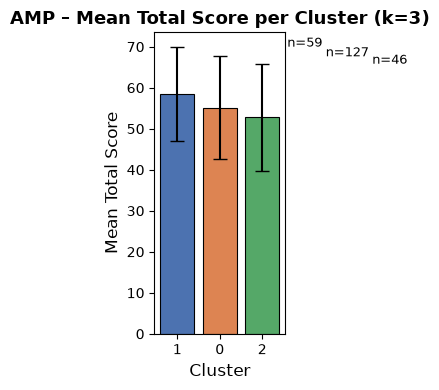

In [41]:
amp_clustered, amp_scaler, amp_kmeans, amp_feat_cols = run_kmeans(amp)

# ── Cluster sizes & average Total_Score ─────────────────────────────────────
amp_score_summary = cluster_score_summary(amp_clustered)
print("=== AMP  |  Cluster Score Summary ===")
display(amp_score_summary)

plot_cluster_scores(amp_score_summary, "AMP – Mean Total Score per Cluster (k=3)")

=== AMP  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===


,Feature,F_statistic,p_value,Cluster_Mean_Spread,Importance
0,BD_bg_level,1519.5476,0.0,27.4516,High
1,BP_bg_level,1169.5208,0.0,33.0416,High
2,BP_p90_to_mean,667.2145,0.0,0.2113,High
3,BP_global_p90,655.4563,0.0,44.3329,High
4,BP_zone_0_3_std,597.4042,0.0,1.5511,High
5,BP_gauss_sigma_x,575.9620,0.0,0.0013,High
6,BD_edge_asymmetry_h,523.5743,0.0,0.0016,High
7,BD_iso_centroid_x,517.5731,0.0,0.0117,High
8,BD_iso_centroid_y,482.9494,0.0,0.0127,High
9,session_id,438.8851,0.0,64.9239,High


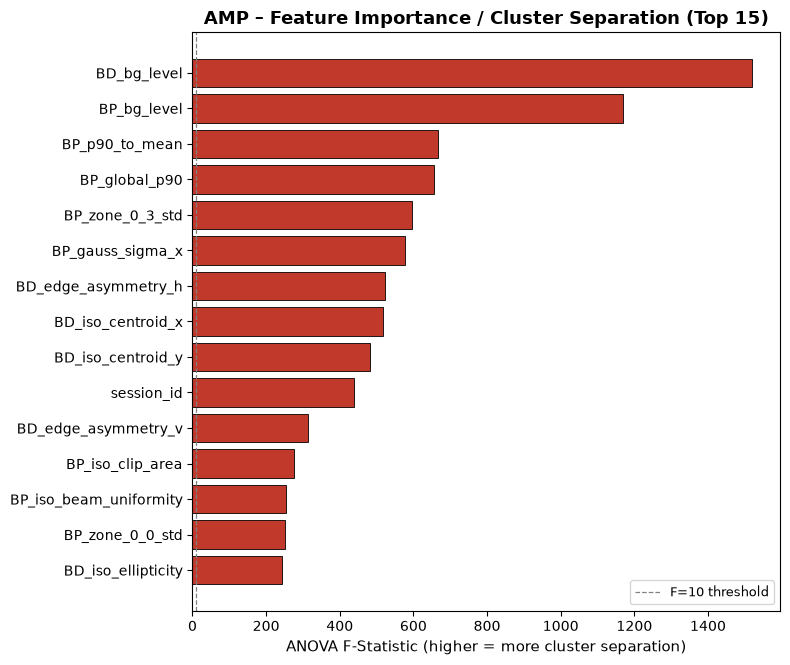

In [38]:
# ── Feature importance / similarity report ───────────────────────────────────
amp_feat_report = feature_importance_report(amp_clustered, amp_feat_cols, top_n=15)
print("=== AMP  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===")
display(amp_feat_report)

plot_feature_importance(amp_feat_report, "AMP – Feature Importance / Cluster Separation (Top 15)")

### OSC — K-Means Clustering

=== OSC  |  Cluster Score Summary ===


,Cluster,Count,Mean_Total_Score,Std_Total_Score,Max_Total_Score,Min_Total_Score
0,0,67,58.279851,13.007612,79.00,25.0
2,2,62,57.262097,12.946329,89.25,26.0
1,1,75,52.596667,12.391209,77.75,24.0


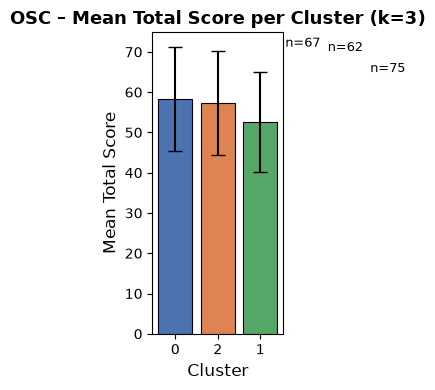

In [42]:
osc_clustered, osc_scaler, osc_kmeans, osc_feat_cols = run_kmeans(osc)

# ── Cluster sizes & average Total_Score ─────────────────────────────────────
osc_score_summary = cluster_score_summary(osc_clustered)
print("=== OSC  |  Cluster Score Summary ===")
display(osc_score_summary)

plot_cluster_scores(osc_score_summary, "OSC – Mean Total Score per Cluster (k=3)")

=== OSC  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===


,Feature,F_statistic,p_value,Cluster_Mean_Spread,Importance
0,BD_iso_eccentricity,2944.9450,0.0,0.0191,High
1,BD_iso_ellipticity,2808.7168,0.0,0.0179,High
2,BD_edge_bottom_frac,2083.8621,0.0,0.0073,High
3,BP_edge_asymmetry_h,1724.2425,0.0,0.0010,High
4,BD_edge_asymmetry_v,1433.1257,0.0,0.0045,High
5,BD_bg_level,1388.3326,0.0,30.0972,High
6,BD_iso_centroid_x,1376.6404,0.0,0.0113,High
7,BD_iso_centroid_y,1232.1815,0.0,0.0136,High
8,BP_bg_level,1189.0959,0.0,41.0477,High
9,BD_edge_asymmetry_h,907.8943,0.0,0.0021,High


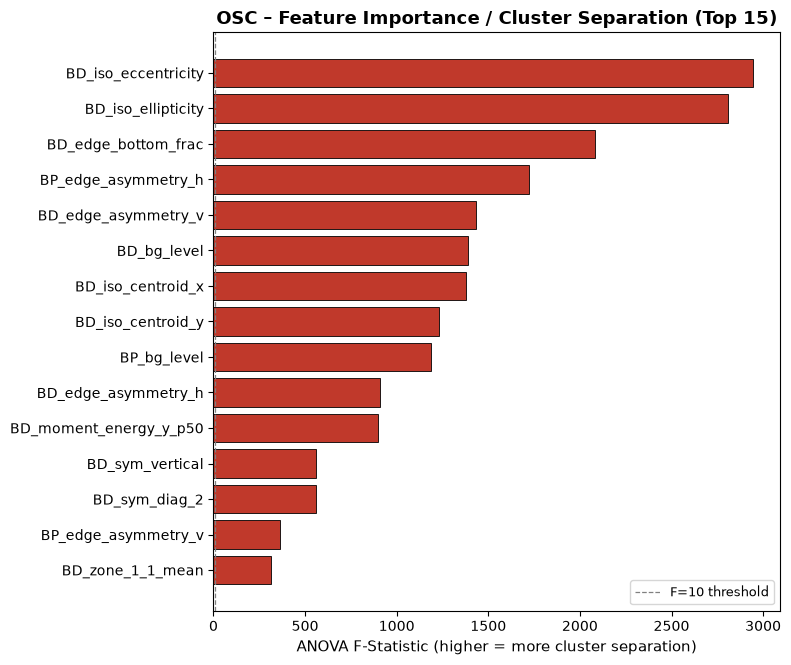

In [30]:
# ── Feature importance / similarity report ───────────────────────────────────
osc_feat_report = feature_importance_report(osc_clustered, osc_feat_cols, top_n=15)
print("=== OSC  |  Top-15 Features by Cluster Separation (ANOVA F-Statistic) ===")
display(osc_feat_report)

plot_feature_importance(osc_feat_report, "OSC – Feature Importance / Cluster Separation (Top 15)")